In [1]:
import pandas as pd
df = pd.read_parquet("/home/aime/overnigh_strat/overnight/data/final_features.parquet")

In [2]:
df = df[(df["trade_date"] >= "2010-01-04") & (df["trade_date"] <= "2024-12-31")]
df["perf_close_to_open"] = df["next_day_open"] / df["orig_close"] - 1.0
df = df.dropna(subset=['perf_close_to_open'])

In [3]:
import numpy as np
import pandas as pd
from typing import Callable, Dict, Union

def get_performance_metric(metric_name: str) -> Callable:

    def mean_std_ratio(x):
        mean = x.mean()
        std = x.std()
        return mean / std if std != 0 else 0
    
    def median_std_ratio(x):
        median = x.median()
        std = x.std()
        return median / std if std != 0 else 0
    
    def mean_abs_std_ratio(x):
        mean = x.mean()
        std = x.std()
        return abs(mean) / std if std != 0 else 0
    
    def median_abs_std_ratio(x):
        median = x.median()
        std = x.std()
        return abs(median) / std if std != 0 else 0
    
    def trimmed_mean_std_ratio(x):
        trimmed = x[(x >= x.quantile(0.01)) & (x <= x.quantile(0.99))]
        mean = trimmed.mean()
        std = trimmed.std()
        return mean / std if std != 0 else 0
    
    metrics = {
        'mean': lambda x: x.mean(),
        'median': lambda x: x.median(),
        'mean_std_ratio': mean_std_ratio,
        'median_std_ratio': median_std_ratio,
        'mean_abs_std_ratio': mean_abs_std_ratio,
        'median_abs_std_ratio': median_abs_std_ratio,
        'trimmed_mean_std_ratio': trimmed_mean_std_ratio
    }
    
    if metric_name not in metrics:
        raise ValueError(f"Unknown metric: {metric_name}. Available metrics: {list(metrics.keys())}")
    
    return metrics[metric_name]

def analyze_feature_range(
    df: pd.DataFrame,
    feature_name: str,
    performance_col: str = 'perf_close_to_open',
    metric: Union[str, Callable] = 'mean',
    n_ranges: int = 10,
    method: str = 'quantile'
) -> pd.DataFrame:
    import warnings
    warnings.filterwarnings('ignore', category=FutureWarning)
    warnings.filterwarnings('ignore', category=RuntimeWarning)
    
    categorical_features = ['ticker', 'day_of_week', 'month', 'year', 'is_short_above_long',
                          "hammer_flag", "doji_flag", "is_short_above_extra_long"]
    
    if isinstance(metric, str):
        perf_metric = get_performance_metric(metric)
        metric_name = metric
    else:
        perf_metric = metric
        metric_name = metric.__name__
    
    def calculate_accuracy(x):
        """Calculate percentage of positive or zero returns"""
        return (x >= 0).mean()
    
    is_categorical = (
        df[feature_name].dtype == 'object' or 
        df[feature_name].dtype.name == 'category' or 
        feature_name in categorical_features
    )
    
    if is_categorical:
        range_stats = df.groupby(feature_name).agg({
            performance_col: ['count', 'std', perf_metric, calculate_accuracy]
        }).round(6)
        range_stats.columns = ['count', 'std', metric_name, 'accuracy']
        range_stats['min_value'] = range_stats.index
        range_stats['max_value'] = range_stats.index
        return range_stats
    
    if not np.issubdtype(df[feature_name].dtype, np.number):
        raise ValueError(f"Feature {feature_name} is neither numeric nor categorical")
    
    feature_data = df[feature_name].replace([np.inf, -np.inf], np.nan)
    
    if method == 'quantile':
        quantiles = np.linspace(0, 1, n_ranges + 1)
        range_edges = feature_data.quantile(quantiles)
        range_edges = pd.Series(sorted(range_edges.unique()))
    else:
        min_val = feature_data.min()
        max_val = feature_data.max()
        if min_val == max_val:
            raise ValueError(f"Feature {feature_name} has no variance")
        range_edges = np.linspace(min_val, max_val, n_ranges + 1)
    
    if len(range_edges) < 3:
        raise ValueError(f"Not enough unique values in {feature_name}")
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        df['range'] = pd.cut(feature_data,
                            bins=range_edges,
                            include_lowest=True,
                            duplicates='drop')
    
    range_stats = df.groupby('range', observed=False).agg({
        performance_col: ['count', 'std', perf_metric, calculate_accuracy],
        feature_name: ['min', 'max']
    }).round(6)
    
    # Flatten column names
    range_stats.columns = ['count', 'std', metric_name, 'accuracy', 'min_value', 'max_value']
    
    return range_stats

def find_best_feature_ranges(
    df: pd.DataFrame,
    features_list: list,
    performance_col: str = 'perf_close_to_open',
    metric: Union[str, Callable] = 'mean',
    n_ranges: int = 10,
    min_samples: int = 1000
) -> Dict:
    import warnings
    warnings.filterwarnings('ignore', category=FutureWarning)
    warnings.filterwarnings('ignore', category=RuntimeWarning)
    
    best_ranges = {}
    metric_name = metric if isinstance(metric, str) else metric.__name__
    
    for feature in features_list:
        try:
            # Skip features with too many NaN values
            nan_ratio = df[feature].isna().mean()
            if nan_ratio > 0.5:
                print(f"Skipping {feature}: too many NaN values ({nan_ratio:.2%})")
                continue
            
            # Get range statistics
            stats = analyze_feature_range(
                df=df,
                feature_name=feature,
                performance_col=performance_col,
                metric=metric,
                n_ranges=n_ranges
            )
            
            # Filter ranges with enough samples
            valid_ranges = stats[stats['count'] >= min_samples]
            
            if not valid_ranges.empty:
                # Find range with highest performance
                best_range_idx = valid_ranges[metric_name].idxmax()
                best_metric = valid_ranges.loc[best_range_idx, metric_name]
                sample_count = valid_ranges.loc[best_range_idx, 'count']
                std_value = valid_ranges.loc[best_range_idx, 'std']
                accuracy = valid_ranges.loc[best_range_idx, 'accuracy']
                
                # Get range bounds
                range_min = valid_ranges.loc[best_range_idx, 'min_value']
                range_max = valid_ranges.loc[best_range_idx, 'max_value']
                
                best_ranges[feature] = {
                    'range': best_range_idx,
                    f'{metric_name}_performance': best_metric,
                    'std': std_value,
                    'accuracy': accuracy,
                    'sample_count': sample_count,
                    'min_value': range_min,
                    'max_value': range_max
                }
            else:
                print(f"Skipping {feature}: no ranges with enough samples")
                
        except Exception as e:
            print(f"Error analyzing {feature}: {str(e)}")
            continue
    
    # Sort dictionary by performance
    sorted_ranges = dict(sorted(
        best_ranges.items(),
        key=lambda x: abs(x[1][f'{metric_name}_performance']),
        reverse=True
    ))
    
    # Print results
    if sorted_ranges:
        print(f"\n=== Best Ranges by Feature (Sorted by |{metric_name}|) ===")
        print("\n{:<30} {:<15} {:<15} {:<15} {:<15} {:<15} {:<15}".format(
            "Feature", f"{metric_name}", "Std", "Accuracy", "Samples", "Min Value", "Max Value"
        ))
        print("-" * 115)
        
        for feature, stats in sorted_ranges.items():
            print("{:<30} {:<15.6f} {:<15.6f} {:<15.6f} {:<15.0f} {:<15} {:<15}".format(
                feature[:30],
                stats[f'{metric_name}_performance'],
                stats['std'],
                stats['accuracy'],
                stats['sample_count'],
                str(stats['min_value'])[:14],
                str(stats['max_value'])[:14]
            ))
    else:
        print("\nNo valid ranges found for any feature")
    
    return sorted_ranges


# Example usage
cols_to_drop=[
    'next_day_open',
    'next_day_date',
    'orig_close',
    'orig_high',
    'orig_low',
    'orig_vol',
    'orig_txn',
    "trade_date",
    "perf_close_to_open",
    "target",
    "ticker",
    "intraday_last_close_before_1555",
    't',
    "total_range_score",
    "range_score_pct",
    "year"

    ]


prices_colums = ["close", 
                 "open", 
                 "high", 
                 "low",
                 "current_day_open", 
                 "typical_price",
                 "short_ma",
                 "long_ma", 
                 "extra_long_ma",
                 "ema_long",
                 "orig_open", 
                 "prev_day_open", 
                 "volume_dollar_prev_day",
                 "typical_price",
                 "intraday_close_auction_dollar_volume",
                 "intraday_open_auction_dollar_volume",
                'roll5_mean_intraday_open_auction_dollar_volume',
                'roll5_mean_intraday_close_auction_dollar_volume',
                'boll_lower']

features_to_analyze = [col for col in df.columns if col not in cols_to_drop and col not in prices_colums]


best_ranges = find_best_feature_ranges(
    df=df,
    features_list=features_to_analyze,
    metric='trimmed_mean_std_ratio',
    n_ranges=30,
    min_samples=1000
)



=== Best Ranges by Feature (Sorted by |trimmed_mean_std_ratio|) ===

Feature                        trimmed_mean_std_ratio Std             Accuracy        Samples         Min Value       Max Value      
-------------------------------------------------------------------------------------------------------------------
intraday_second_half_day_retur 0.200051        1.650462        0.617069        515284          -0.893843       -0.028642      
intraday_last_hour_return      0.193387        1.263237        0.618650        501274          -0.773438       -0.018018      
roll50_opens_above_prev_close_ 0.189734        4.711349        0.616984        313316          0.68            0.92           
intraday_close_to_vwap         0.187579        1.813472        0.611906        525602          -0.814235       -0.024404      
roll10_opens_above_prev_close_ 0.186978        0.467571        0.613208        206589          0.9             1.0            
intraday_last_half_hour_return 0.185119      

In [4]:
best_ranges

{'intraday_second_half_day_return': {'range': Interval(-0.895, -0.0286, closed='right'),
  'trimmed_mean_std_ratio_performance': np.float64(0.200051),
  'std': np.float64(1.650462),
  'accuracy': np.float64(0.617069),
  'sample_count': np.int64(515284),
  'min_value': np.float64(-0.893843),
  'max_value': np.float64(-0.028642)},
 'intraday_last_hour_return': {'range': Interval(-0.774, -0.018, closed='right'),
  'trimmed_mean_std_ratio_performance': np.float64(0.193387),
  'std': np.float64(1.263237),
  'accuracy': np.float64(0.61865),
  'sample_count': np.int64(501274),
  'min_value': np.float64(-0.773438),
  'max_value': np.float64(-0.018018)},
 'roll50_opens_above_prev_close_count': {'range': Interval(0.66, 0.92, closed='right'),
  'trimmed_mean_std_ratio_performance': np.float64(0.189734),
  'std': np.float64(4.711349),
  'accuracy': np.float64(0.616984),
  'sample_count': np.int64(313316),
  'min_value': np.float64(0.68),
  'max_value': np.float64(0.92)},
 'intraday_close_to_vwap':

In [6]:
def create_scoring_features(
    df: pd.DataFrame, 
    best_ranges: Union[dict, pd.DataFrame], 
    metric: str = 'mean_std_ratio_performance', 
    min_performance: float = 0.06,
    max_negative_performance: float = -0.03
) -> tuple[pd.DataFrame, list, dict]:
    """
    Create accuracy-based scoring features based on good and bad performing ranges.
    
    Args:
        df: Input DataFrame with features
        best_ranges: Dictionary or DataFrame containing range information for features
        metric: Name of the performance metric column
        min_performance: Minimum performance threshold for good ranges
        max_negative_performance: Maximum performance threshold for bad ranges
        
    Returns:
        tuple: (DataFrame with new features, list of binary feature names, rules information)
    """
    # Setup and validation
    if not isinstance(best_ranges, pd.DataFrame):
        best_ranges = pd.DataFrame.from_dict(best_ranges, orient='index')
    
    if metric not in best_ranges.columns:
        raise ValueError(f"Metric '{metric}' not found in best_ranges columns: {best_ranges.columns.tolist()}")
    
    required_cols = ['range', 'min_value', 'max_value', 'accuracy']
    missing_cols = [col for col in required_cols if col not in best_ranges.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in best_ranges: {missing_cols}")
    
    # Initialize tracking variables
    accuracy_features = []
    rules_info = {
        'good_rules': [],
        'bad_rules': []
    }
    
    # Define categorical features
    categorical_features = [
        'ticker', 'day_of_week', 'month', 'year', 
        'is_short_above_long', 'is_short_above_extra_long',
        'hammer_flag', 'doji_flag'
    ]
    
    def process_categorical_feature(feature: str, row: pd.Series, is_good_rule: bool) -> tuple[str, pd.Series]:
        """Helper function to process categorical features"""
        category = row['range']
        accuracy = row['accuracy'] if is_good_rule else (1 - row['accuracy'])
        
        if is_good_rule:
            feature_name = f"{feature}_in_good_range"
            binary_values = (df[feature] == category).astype(float) * accuracy
            condition = f"{feature} == {category}"
        else:
            feature_name = f"{feature}_outside_bad_range"
            binary_values = (df[feature] != category).astype(float) * accuracy
            condition = f"{feature} != {category}"
            
        return feature_name, binary_values, condition
    
    def process_numerical_feature(feature: str, row: pd.Series, is_good_rule: bool) -> tuple[str, pd.Series]:
        """Helper function to process numerical features"""
        min_val = row['min_value'].left if hasattr(row['min_value'], 'left') else row['min_value']
        max_val = row['max_value'].right if hasattr(row['max_value'], 'right') else row['max_value']
        accuracy = row['accuracy'] if is_good_rule else (1 - row['accuracy'])
        
        if is_good_rule:
            feature_name = f"{feature}_in_good_range"
            binary_values = ((df[feature] >= min_val) & (df[feature] <= max_val)).astype(float) * accuracy
            condition = f"{min_val:.4f} <= {feature} <= {max_val:.4f}"
        else:
            feature_name = f"{feature}_outside_bad_range"
            binary_values = ((df[feature] < min_val) | (df[feature] > max_val)).astype(float) * accuracy
            condition = f"{feature} < {min_val:.4f} OR {feature} > {max_val:.4f}"
            
        return feature_name, binary_values, condition
    
    def process_features(features_df: pd.DataFrame, is_good_rule: bool):
        """Process a set of features and create accuracy-weighted indicators"""
        rule_type = 'good_rules' if is_good_rule else 'bad_rules'
        
        for feature, row in features_df.iterrows():
            try:
                is_categorical = (
                    feature in categorical_features or 
                    df[feature].dtype.name in ['object', 'category']
                )
                
                if is_categorical:
                    feature_name, accuracy_values, condition = process_categorical_feature(
                        feature, row, is_good_rule
                    )
                    feature_type = 'categorical'
                else:
                    feature_name, accuracy_values, condition = process_numerical_feature(
                        feature, row, is_good_rule
                    )
                    feature_type = 'numerical'
                
                # Add accuracy-weighted feature to DataFrame
                df[feature_name] = accuracy_values
                accuracy_features.append(feature_name)
                
                # Record rule information with appropriate accuracy
                used_accuracy = row['accuracy'] if is_good_rule else (1 - row['accuracy'])
                rules_info[rule_type].append({
                    'feature': feature,
                    'type': feature_type,
                    'condition': condition,
                    'performance': row[metric],
                    'original_accuracy': row['accuracy'],
                    'used_accuracy': used_accuracy
                })
                
            except Exception as e:
                print(f"Error processing feature {feature}: {str(e)}")
                continue
    
    # Process good and bad performing ranges
    good_features_df = best_ranges[best_ranges[metric] >= min_performance]
    bad_features_df = best_ranges[best_ranges[metric] <= max_negative_performance]
    
    process_features(good_features_df, is_good_rule=True)
    process_features(bad_features_df, is_good_rule=False)
    
    # Calculate total accuracy score
    df['total_accuracy_score'] = df[accuracy_features].sum(axis=1)
    df['accuracy_score_pct'] = (
        df['total_accuracy_score'] / len(accuracy_features) if accuracy_features else 0.0
    )
    
    # Print summary
    print_rules_summary(rules_info, accuracy_features)
    
    return df, accuracy_features, rules_info

def print_rules_summary(rules_info: dict, accuracy_features: list):
    """Print a formatted summary of the rules"""
    print("\n=== Rules Summary ===")
    print(f"Total Rules: {len(accuracy_features)}")
    print(f"Good Rules: {len(rules_info['good_rules'])}")
    print(f"Bad Rules: {len(rules_info['bad_rules'])}")
    
    def print_rules_section(rules: list, section_title: str):
        print(f"\n=== {section_title} ===")
        if not rules:
            print("No rules found")
            return
            
        rules_df = pd.DataFrame(rules)
        rules_df = rules_df.sort_values('used_accuracy', ascending=False)
        
        for _, rule in rules_df.iterrows():
            print(f"{rule['feature']} ({rule['type']})")
            print(f"Condition: {rule['condition']}")
            print(f"Performance: {rule['performance']:.4f}")
            print(f"Original Accuracy: {rule['original_accuracy']:.4f}")
            print(f"Used Accuracy: {rule['used_accuracy']:.4f}\n")
    
    print_rules_section(rules_info['good_rules'], "Good Rules (Sorted by Accuracy)")
    print_rules_section(rules_info['bad_rules'], "Bad Rules to Avoid (Sorted by Accuracy)")


# Example usage:
scored_df, binary_features, rules_info = create_scoring_features(
    df=df,
    best_ranges=best_ranges,
    metric='trimmed_mean_std_ratio_performance',
    min_performance=0.10,
    max_negative_performance=0.06
)

# Add back required columns
scored_df['trade_date'] = df['trade_date']
scored_df['orig_close'] = df['orig_close'] 
scored_df['close'] = df['close'] 
scored_df['next_day_open'] = df['next_day_open']
scored_df["roll5_mean_intraday_close_auction_dollar_volume"] = df["roll5_mean_intraday_close_auction_dollar_volume"]

scored_df = scored_df[["ticker",
                      "total_accuracy_score", 
                      "trade_date",
                      "orig_close", 
                      "close",
                      "next_day_open",
                      "roll5_mean_intraday_close_auction_dollar_volume",
                      "roll5_mean_intraday_total_dollar_volume_all"]]


=== Rules Summary ===
Total Rules: 76
Good Rules: 62
Bad Rules: 14

=== Good Rules (Sorted by Accuracy) ===
vix_range_prev_day (numerical)
Condition: 0.1192 <= vix_range_prev_day <= 0.1273
Performance: 0.1719
Original Accuracy: 0.6252
Used Accuracy: 0.6252

intraday_last_half_hour_return (numerical)
Condition: -0.6469 <= intraday_last_half_hour_return <= -0.0132
Performance: 0.1851
Original Accuracy: 0.6207
Used Accuracy: 0.6207

intraday_last_quarter_hour_return (numerical)
Condition: -0.8100 <= intraday_last_quarter_hour_return <= -0.0107
Performance: 0.1764
Original Accuracy: 0.6199
Used Accuracy: 0.6199

intraday_last_hour_return (numerical)
Condition: -0.7734 <= intraday_last_hour_return <= -0.0180
Performance: 0.1934
Original Accuracy: 0.6187
Used Accuracy: 0.6187

intraday_second_half_day_return (numerical)
Condition: -0.8938 <= intraday_second_half_day_return <= -0.0286
Performance: 0.2001
Original Accuracy: 0.6171
Used Accuracy: 0.6171

roll50_opens_above_prev_close_count (nu

In [8]:
pd.set_option('display.float_format', lambda x: '%.6f' % x)

scored_df["total_accuracy_score"].describe()

count   15785065.000000
mean           5.797919
std            2.128655
min            0.000000
25%            4.808598
50%            5.248184
75%            6.007473
max           30.565096
Name: total_accuracy_score, dtype: float64


=== Similar Scores Monitoring ===
Total trading days: 3774
Days with similar scores: 1621
Percentage of days with similar scores: 42.95%

Sample of similar scores events:
        date  n_similar_positions  n_selected         score_range  \
0 2010-01-04                   12          10   9.0340 to 13.1528   
1 2010-01-07                   12          10  10.1177 to 12.3326   
2 2010-01-08                   11          10  10.5568 to 15.5944   
3 2010-01-12                   11          10  11.0810 to 14.4412   
4 2010-01-13                   11          10   9.4859 to 11.7664   

                                     selected_scores  \
0  [13.152767, 11.909642000000002, 10.87327500000...   
1  [12.332581000000001, 12.179077999999999, 11.75...   
2  [15.594396, 13.103097, 12.487671000000002, 12....   
3  [14.441239000000001, 13.680257000000003, 13.07...   
4  [11.766397, 11.611742000000001, 11.162077, 10....   

                                  all_similar_scores  \
0  [13.152767, 11.90

/tmp/ipykernel_125894/21404287.py:249: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  annual_performance = daily_results.groupby('year').apply(


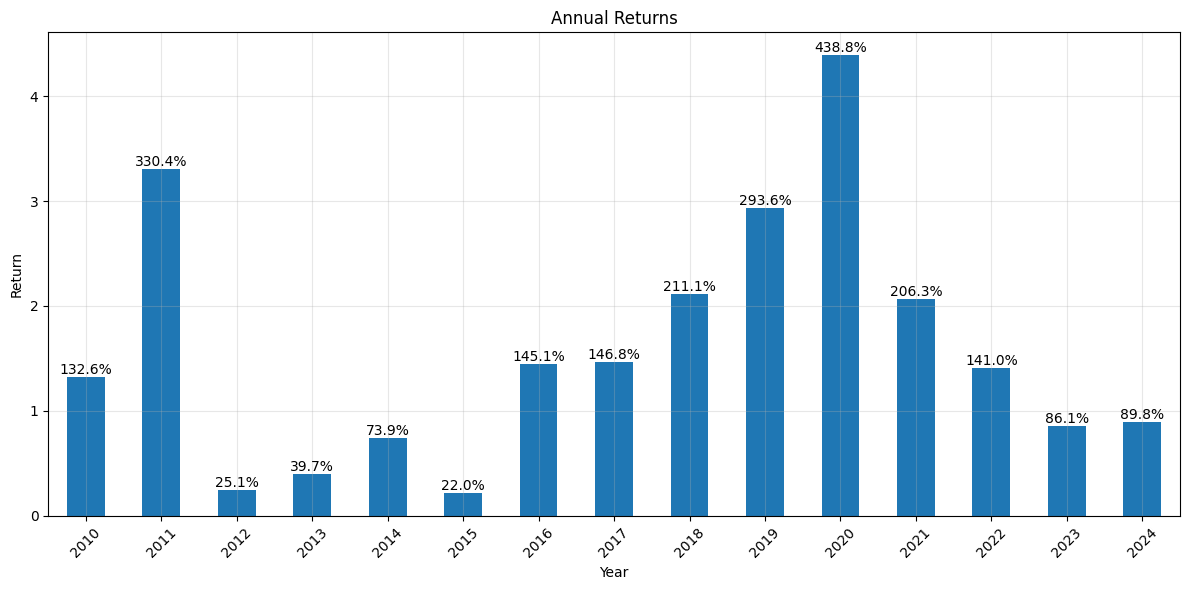


Performance Stats:
final_capital: 19290904160.8932
final_cum_return: 385817.0832
max_drawdown: 0.4106
annualized_return: 1.3606
mar_ratio: 3.3134
annualized_volatility: 0.4040
sharpe_ratio: 3.3680
total_trades: 37740.0000
win_rate: 0.4759
avg_return_per_trade: 0.0037
avg_positions_per_day: 10.0000

Position Statistics:
Total Trades: 37740
Win Rate: 47.59%
Average Return per Trade: 0.37%

Top 5 Performing Tickers:
       net_return                   probability
            count     mean      std        mean
ticker                                         
CRTD            1 0.680200      NaN   14.302500
CHEF            2 0.466100 0.664300   16.646700
RETA            5 0.366900 0.806600   14.605700
PURE            1 0.308200      NaN   16.079200
HAWK           19 0.259400 1.164400   13.202300


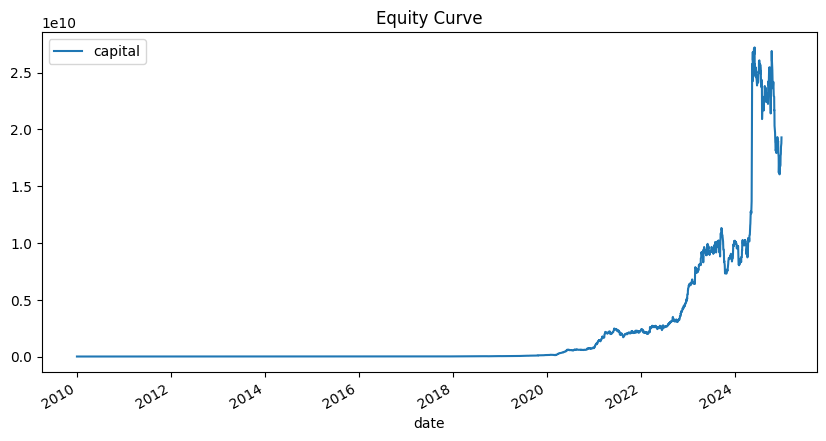

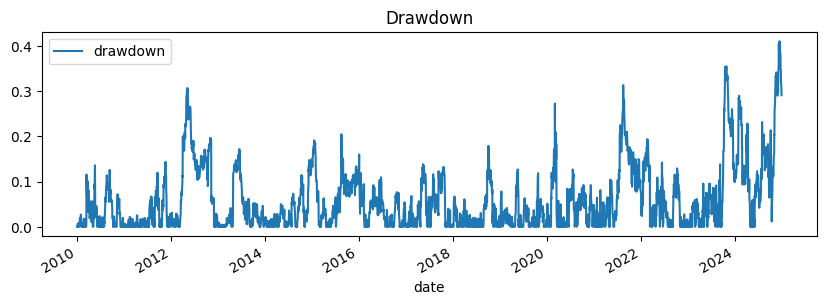

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def add_momentum_ranking(df,liquidity_threshold, price_threshold):
    """
    Calculate 5-day close-to-close performance and rank tickers by this performance for each day.
    Rank 1 = highest performance.
    """

    df = df[df['roll5_mean_intraday_total_dollar_volume_all'] > liquidity_threshold]
    df = df[df['orig_close'] > price_threshold]

    # Calculate 5-day close-to-close performance
    df = df.sort_values(['ticker', 'trade_date']).copy()
    df['close_5d_ago'] = df.groupby('ticker')['close'].shift(5)
    df['perf_5d'] = df['close'] / df['close_5d_ago'] - 1
    
    # Rank tickers by performance for each day (1 = highest performance)
    df['momentum_ranking'] = df.groupby('trade_date')['perf_5d'].rank(ascending=False)
    
    # Clean up intermediate columns
    df = df.drop(['close_5d_ago', 'perf_5d'], axis=1)
    
    return df

def backtest_with_commission(
    df,
    threshold=0.35,
    max_positions=10,
    initial_capital=50000,
    date_col='trade_date',
    open_col='orig_close',       # buy price at day's close
    next_open_col='next_day_open',  # sell price next day
    probas_col='total_range_score',
    liquidity_threshold=10000,
    price_threshold=1,
    top_n_momentum=30,
    score_similarity_threshold=0.1  # New parameter for monitoring
):
    if top_n_momentum is not None:
        df = add_momentum_ranking(df, liquidity_threshold, price_threshold)
        df = df[df["momentum_ranking"] < top_n_momentum]
    # Sort by date
    df_sorted = df.sort_values(by=date_col).reset_index(drop=True)
    grouped = df_sorted.groupby(date_col, as_index=False)
    
    # Initialize tracking variables
    daily_records = []
    positions_list = []  # For tracking individual positions
    similar_scores_events = []  # For monitoring similar scores
    capital = initial_capital
    unique_dates = df_sorted[date_col].unique()



    def net_return_with_commission(raw_return):
        """Calculate net return after commission"""
        entry_after_commission = 1 + 0.0015  # Pay 1.5% more on entry
        exit_after_commission = 1 - 0.0015
        return (1 + raw_return) * exit_after_commission / entry_after_commission - 1

    def monitor_similar_scores(qualified_df, selected_positions, day, similarity_threshold):
        """Monitor and log occurrences of similar scores"""
        if len(qualified_df) <= len(selected_positions):
            return
            
        cutoff_score = selected_positions[probas_col].min()
        max_score = selected_positions[probas_col].max()
        
        # Find positions with similar scores to those selected
        similar_scores_mask = (
            (qualified_df[probas_col] >= cutoff_score - similarity_threshold) &
            (qualified_df[probas_col] <= max_score + similarity_threshold)
        )
        similar_scores_df = qualified_df[similar_scores_mask]
        
        if len(similar_scores_df) > len(selected_positions):
            similar_scores_events.append({
                'date': day,
                'n_similar_positions': len(similar_scores_df),
                'n_selected': len(selected_positions),
                'score_range': f"{similar_scores_df[probas_col].min():.4f} to {similar_scores_df[probas_col].max():.4f}",
                'selected_scores': selected_positions[probas_col].tolist(),
                'all_similar_scores': similar_scores_df[probas_col].tolist(),
                'selected_tickers': selected_positions['ticker'].tolist(),
                'all_similar_tickers': similar_scores_df['ticker'].tolist()
            })

    # Loop through each trading day
    for day in unique_dates:
        day_data = grouped.get_group(day)
        
        # Filter for minimum liquidity
        qualified_liquidity = day_data[
            day_data['roll5_mean_intraday_total_dollar_volume_all'] > liquidity_threshold
        ]
        qualified_price = qualified_liquidity[
            qualified_liquidity['orig_close'] > price_threshold
        ]

        qualified_price = qualified_price.copy()  # Create copy to avoid SettingWithCopyWarning
        qualified_price[probas_col] = qualified_price[probas_col]#.round(1)

          # Sort by both criteria first
        qualified_price = qualified_price.sort_values(
            by=[probas_col, 'roll5_mean_intraday_total_dollar_volume_all'],
            ascending=[False, False]
        )

   
        # Filter by probability threshold
        qualified = qualified_price[
            qualified_price[probas_col] >= threshold
        ].dropna(subset=[open_col, next_open_col, probas_col])

        
        if len(qualified) == 0:
            daily_return = 0.0
            n_positions = 0
        else:
            

            topN = qualified.head(max_positions)

            # Select top N positions
            #topN = qualified.sort_values(probas_col, #ascending=False).head(max_positions)
            n_positions = len(topN)

            position_size = initial_capital / n_positions
            
            # Monitor similar scores
            #monitor_similar_scores(qualified, topN, day, score_similarity_threshold)
            
            # Calculate returns
            raw_returns = topN[next_open_col] / topN[open_col] - 1.0
            net_returns = raw_returns.apply(net_return_with_commission)
            daily_return = net_returns.mean()
            
            # Record individual positions
            for idx, row in topN.iterrows():
                raw_return = row[next_open_col] / row[open_col] - 1.0
                net_return = net_return_with_commission(raw_return)
                
                position_info = {
                    'date': day,
                    'ticker': row['ticker'],
                    'entry_price': row[open_col],
                    'exit_price': row[next_open_col],
                    'raw_return': raw_return,
                    'net_return': net_return,
                    'probability': row[probas_col],
                    'volume': row['roll5_mean_intraday_total_dollar_volume_all'],
                    'position_size': position_size,
                    'pnl': position_size * net_return
                }
                positions_list.append(position_info)

        # Update capital
        capital = capital * (1.0 + daily_return)
        
        # Record daily summary
        daily_records.append({
            'date': day,
            'daily_return': daily_return,
            'capital': capital,
            'n_positions': n_positions
        })

    # Create DataFrames
    daily_df = pd.DataFrame(daily_records)
    daily_df.sort_values('date', inplace=True)
    daily_df.set_index('date', inplace=True)

    positions_df = pd.DataFrame(positions_list)
    if len(positions_df) > 0:
        positions_df['win'] = positions_df['net_return'] > 0
    
    # Calculate performance metrics
    daily_df['cum_return'] = daily_df['capital'] / initial_capital - 1.0
    
    # Drawdown calculation
    running_max = daily_df['capital'].cummax()
    daily_df['drawdown'] = 1 - (daily_df['capital'] / running_max)
    max_dd = daily_df['drawdown'].max()

    # Annualized metrics
    total_days = len(daily_df)
    if total_days < 2:
        annual_return = np.nan
    else:
        final_cum_return = daily_df['cum_return'].iloc[-1]
        annual_return = (1 + final_cum_return)**(252 / total_days) - 1

    daily_std = daily_df['daily_return'].std()
    annual_vol = daily_std * np.sqrt(252)

    mar_ratio = annual_return / max_dd

    # Sharpe Ratio
    if not np.isnan(annual_vol) and annual_vol > 1e-12:
        sharpe = annual_return / annual_vol
    else:
        sharpe = np.nan

    # Compile statistics
    stats = {
        'final_capital': capital,
        'final_cum_return': daily_df['cum_return'].iloc[-1],
        'max_drawdown': max_dd,
        'annualized_return': annual_return,
        'mar_ratio': mar_ratio,
        'annualized_volatility': annual_vol,
        'sharpe_ratio': sharpe,
        'total_trades': len(positions_df),
        'win_rate': positions_df['win'].mean() if len(positions_df) > 0 else 0,
        'avg_return_per_trade': positions_df['net_return'].mean() if len(positions_df) > 0 else 0,
        'avg_positions_per_day': daily_df['n_positions'].mean()
    }

    # Create similar scores monitoring DataFrame
    similar_scores_df = pd.DataFrame(similar_scores_events)
    
    # Print summary of similar scores events
    if len(similar_scores_events) > 0:
        print("\n=== Similar Scores Monitoring ===")
        print(f"Total trading days: {len(unique_dates)}")
        print(f"Days with similar scores: {len(similar_scores_events)}")
        print(f"Percentage of days with similar scores: {(len(similar_scores_events)/len(unique_dates))*100:.2f}%")
        
        print("\nSample of similar scores events:")
        pd.set_option('display.max_columns', None)
        print(similar_scores_df.head())
        
        # Additional statistics
        avg_similar = similar_scores_df['n_similar_positions'].mean()
        print(f"\nAverage number of similar positions when event occurs: {avg_similar:.2f}")
    else:
        print("\nNo instances of similar scores found")

    return daily_df, stats, positions_df, similar_scores_df

def analyze_annual_performance(daily_results):
    """
    Analyze and plot annual performance metrics from backtest results
    """
    # Add year to daily_df if not already present
    daily_results = daily_results.copy()
    daily_results['year'] = daily_results.index.year
    
    # Calculate annual performance
    annual_performance = daily_results.groupby('year').apply(
        lambda x: {
            'return': (1 + x['daily_return']).prod() - 1,
            'sharpe': x['daily_return'].mean() / x['daily_return'].std() * np.sqrt(252) if len(x) > 1 else 0,
            'max_drawdown': x['drawdown'].max(),
            'avg_positions': x['n_positions'].mean()
        }
    ).apply(pd.Series)
    
    # Plot annual performance
    plt.figure(figsize=(12, 6))
    annual_performance['return'].plot(kind='bar')
    plt.title('Annual Returns')
    plt.xlabel('Year')
    plt.ylabel('Return')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Add return values on top of bars
    for i, v in enumerate(annual_performance['return']):
        plt.text(i, v, f'{v:.1%}', ha='center', va='bottom' if v > 0 else 'top')
    
    plt.tight_layout()
    plt.show()
    
    return annual_performance


# Run the backtest
daily_results, performance, positions_df, similar_scores_df = backtest_with_commission(
    df=scored_df.dropna(subset=['total_accuracy_score']), 
    threshold=7,
    max_positions=10,
    initial_capital=50000,
    date_col='trade_date',
    open_col='orig_close',
    next_open_col='next_day_open',
    probas_col='total_accuracy_score',
    liquidity_threshold=1000000,
    top_n_momentum=None,
    price_threshold=3
)

annual_performance = analyze_annual_performance(daily_results)

# Print performance summary
print("\nPerformance Stats:")
for k, v in performance.items():
    print(f"{k}: {v:.4f}")

# Print position analysis
if len(positions_df) > 0:
    print("\nPosition Statistics:")
    print(f"Total Trades: {len(positions_df)}")
    print(f"Win Rate: {positions_df['win'].mean():.2%}")
    print(f"Average Return per Trade: {positions_df['net_return'].mean():.2%}")
    
    # Top performing tickers
    print("\nTop 5 Performing Tickers:")
    ticker_stats = positions_df.groupby('ticker').agg({
        'net_return': ['count', 'mean', 'std'],
        'probability': 'mean'
    }).round(4)
    print(ticker_stats.sort_values(('net_return', 'mean'), ascending=False).head())

# Plot equity curve
daily_results[['capital']].plot(figsize=(10, 5), title='Equity Curve')
plt.show()

# Plot drawdown
daily_results[['drawdown']].plot(figsize=(10, 3), title='Drawdown')
plt.show()


#sharpe_ratio: 6.7875


/tmp/ipykernel_111085/3365012958.py:162: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  annual_performance = daily_results.groupby('year').apply(


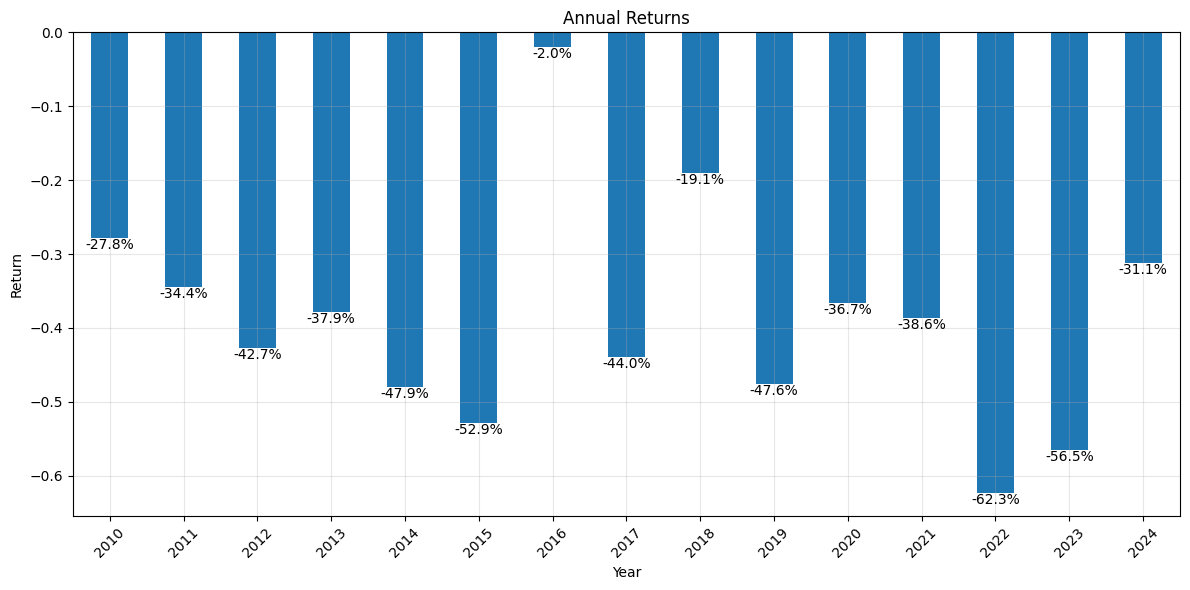


Performance Stats:
final_capital: 21.1219
final_cum_return: -0.9996
max_drawdown: 0.9996
annualized_return: -0.4048
annualized_volatility: 0.3199
sharpe_ratio: -1.2654
total_trades: 11322.0000
win_rate: 0.3922
avg_return_per_trade: -0.0019
avg_positions_per_day: 3.0000

Position Statistics:
Total Trades: 11322
Win Rate: 39.22%
Average Return per Trade: -0.19%

Top 5 Performing Tickers:
       net_return                   probability
            count     mean      std        mean
ticker                                         
HTZ             7 0.425200 1.138900    4.694500
LRN             1 0.123300      NaN    4.547000
ANDS            1 0.111600      NaN    3.971400
WOW             1 0.110300      NaN    4.529500
IDXG            1 0.081400      NaN    3.988200


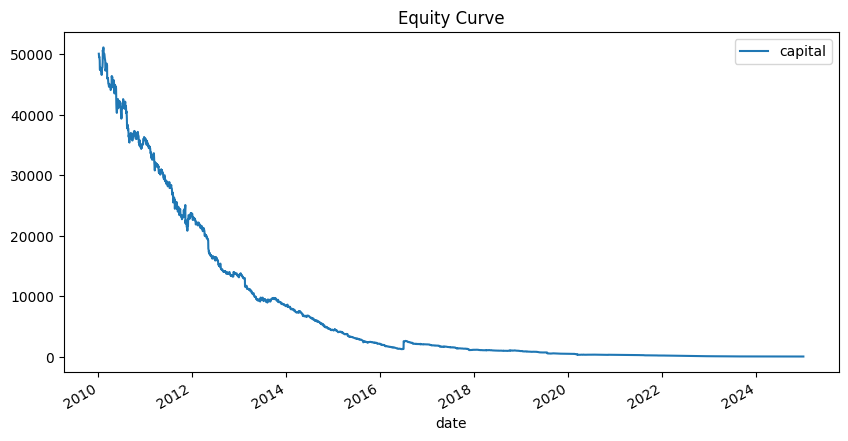

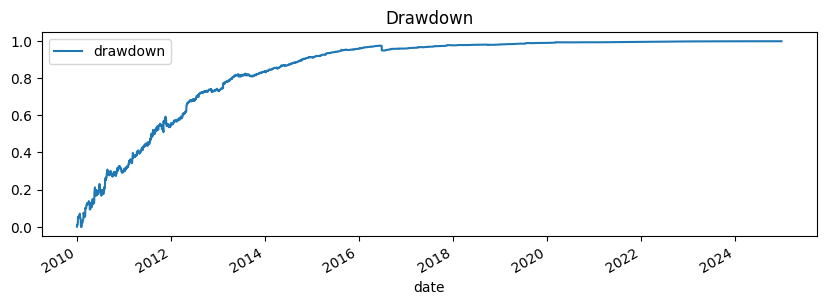

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def backtest_with_commission(
    df,
    threshold=0.35,
    max_positions=10,
    initial_capital=50000,
    date_col='trade_date',
    open_col='orig_close',       # buy price at day's close
    next_open_col='next_day_open',  # sell price next day
    probas_col='total_range_score',
    liquidity_threshold=10000,
    price_threshold=1
):
    
    # Sort by date
    df_sorted = df.sort_values(by=date_col).reset_index(drop=True)
    grouped = df_sorted.groupby(date_col, as_index=False)
    
    # Initialize tracking variables
    daily_records = []
    positions_list = []  # For tracking individual positions
    capital = initial_capital
    unique_dates = df_sorted[date_col].unique()

    def net_return_with_commission(raw_return):
        """Calculate net return after commission"""

        entry_after_commission = 1 + 0.0015 # Pay 1.5% more on entry
        exit_after_commission = 1 - 0.0015
        return (1 + raw_return) * exit_after_commission / entry_after_commission - 1
        #return 0.999 * (1 + raw_return) - 1

    # Loop through each trading day
    for day in unique_dates:
        day_data = grouped.get_group(day)
        
        # Filter for minimum liquidity
        qualified_liquidity = day_data[
            day_data['roll5_mean_intraday_total_dollar_volume_all'] > liquidity_threshold
        ]
        qualified_price = qualified_liquidity[
            qualified_liquidity['orig_close'] > price_threshold
        ]

        # Filter by probability threshold
        qualified = qualified_price[
            qualified_price[probas_col] >= threshold
        ].dropna(subset=[open_col, next_open_col, probas_col])
        
        if len(qualified) == 0:
            daily_return = 0.0
            n_positions = 0
        else:
            # Select top N positions by probability
            topN = qualified.sort_values(probas_col, ascending=False).head(max_positions)
            n_positions = len(topN)
            
            # Calculate returns
            raw_returns = topN[next_open_col] / topN[open_col] - 1.0
            net_returns = raw_returns.apply(net_return_with_commission)
            daily_return = net_returns.mean()
            
            # Record individual positions
            for idx, row in topN.iterrows():
                raw_return = row[next_open_col] / row[open_col] - 1.0
                net_return = net_return_with_commission(raw_return)
                
                position_info = {
                    'date': day,
                    'ticker': row['ticker'],
                    'entry_price': row[open_col],
                    'exit_price': row[next_open_col],
                    'raw_return': raw_return,
                    'net_return': net_return,
                    'probability': row[probas_col],
                    'volume': row['roll5_mean_intraday_total_dollar_volume_all'],
                    'position_size': initial_capital / max_positions,
                    'pnl': (initial_capital / max_positions) * net_return
                }
                positions_list.append(position_info)

        # Update capital
        capital = capital * (1.0 + daily_return)
        
        # Record daily summary
        daily_records.append({
            'date': day,
            'daily_return': daily_return,
            'capital': capital,
            'n_positions': n_positions
        })

    # Create daily DataFrame
    daily_df = pd.DataFrame(daily_records)
    daily_df.sort_values('date', inplace=True)
    daily_df.set_index('date', inplace=True)

    # Create positions DataFrame
    positions_df = pd.DataFrame(positions_list)
    if len(positions_df) > 0:  # Only if we have positions
        positions_df['win'] = positions_df['net_return'] > 0
    
    # Calculate performance metrics
    daily_df['cum_return'] = daily_df['capital'] / initial_capital - 1.0
    
    # Drawdown calculation
    running_max = daily_df['capital'].cummax()
    daily_df['drawdown'] = 1 - (daily_df['capital'] / running_max)
    max_dd = daily_df['drawdown'].max()

    # Annualized metrics
    total_days = len(daily_df)
    if total_days < 2:
        annual_return = np.nan
    else:
        final_cum_return = daily_df['cum_return'].iloc[-1]
        annual_return = (1 + final_cum_return)**(252 / total_days) - 1

    daily_std = daily_df['daily_return'].std()
    annual_vol = daily_std * np.sqrt(252)

    # Sharpe Ratio
    if not np.isnan(annual_vol) and annual_vol > 1e-12:
        sharpe = annual_return / annual_vol
    else:
        sharpe = np.nan

    # Compile statistics
    stats = {
        'final_capital': capital,
        'final_cum_return': daily_df['cum_return'].iloc[-1],
        'max_drawdown': max_dd,
        'annualized_return': annual_return,
        'annualized_volatility': annual_vol,
        'sharpe_ratio': sharpe,
        'total_trades': len(positions_df),
        'win_rate': positions_df['win'].mean() if len(positions_df) > 0 else 0,
        'avg_return_per_trade': positions_df['net_return'].mean() if len(positions_df) > 0 else 0,
        'avg_positions_per_day': daily_df['n_positions'].mean()
    }

    return daily_df, stats, positions_df


def analyze_annual_performance(daily_results):
    """
    Analyze and plot annual performance metrics from backtest results
    
    Parameters:
    daily_results (pd.DataFrame): DataFrame with daily backtest results
    
    Returns:
    pd.DataFrame: Annual performance statistics
    """
    # Add year to daily_df if not already present
    daily_results = daily_results.copy()
    daily_results['year'] = daily_results.index.year
    
    # Calculate annual performance
    annual_performance = daily_results.groupby('year').apply(
        lambda x: {
            'return': (1 + x['daily_return']).prod() - 1,
            'sharpe': x['daily_return'].mean() / x['daily_return'].std() * np.sqrt(252) if len(x) > 1 else 0,
            'max_drawdown': x['drawdown'].max(),
            'avg_positions': x['n_positions'].mean()
        }
    ).apply(pd.Series)
    
    # Plot annual performance
    plt.figure(figsize=(12, 6))
    annual_performance['return'].plot(kind='bar')
    plt.title('Annual Returns')
    plt.xlabel('Year')
    plt.ylabel('Return')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Add return values on top of bars
    for i, v in enumerate(annual_performance['return']):
        plt.text(i, v, f'{v:.1%}', ha='center', va='bottom' if v > 0 else 'top')
    
    plt.tight_layout()
    plt.show()
    
    # Print annual statistics
    #print("\nAnnual Statistics:")
    #print(annual_performance.round(4))
    
    return annual_performance


scored_df

# Run the backtest
daily_results, performance, positions_df = backtest_with_commission(
    df=scored_df.dropna(subset=['total_accuracy_score']), 
    threshold=2,
    max_positions=3,
    initial_capital=50000,
    date_col='trade_date',
    open_col='orig_close',
    next_open_col='next_day_open',
    probas_col='total_accuracy_score',
    liquidity_threshold=1000000,
    price_threshold=2
)

annual_performance = analyze_annual_performance(daily_results)

# Print performance summary
print("\nPerformance Stats:")
for k, v in performance.items():
    print(f"{k}: {v:.4f}")

# Print position analysis
if len(positions_df) > 0:
    print("\nPosition Statistics:")
    print(f"Total Trades: {len(positions_df)}")
    print(f"Win Rate: {positions_df['win'].mean():.2%}")
    print(f"Average Return per Trade: {positions_df['net_return'].mean():.2%}")
    
    # Top performing tickers
    print("\nTop 5 Performing Tickers:")
    ticker_stats = positions_df.groupby('ticker').agg({
        'net_return': ['count', 'mean', 'std'],
        'probability': 'mean'
    }).round(4)
    print(ticker_stats.sort_values(('net_return', 'mean'), ascending=False).head())

# Plot equity curve
daily_results[['capital']].plot(figsize=(10, 5), title='Equity Curve')
plt.show()

# Plot drawdown
daily_results[['drawdown']].plot(figsize=(10, 3), title='Drawdown')
plt.show()